# Lesson 08 - Logistic Regression and the Sigmoid

**Phase 1: The First Networks** &nbsp;|&nbsp; Deep Learning From Scratch

> Turn a line into a probability and derive the sigmoid gradient.

Runs top to bottom on Kaggle, Colab or locally. Nothing to download.

---

## 1. Plan

**What we build today**

A classifier. We squash the linear output $wx + b$ through a **sigmoid** to
get a number between 0 and 1, interpret it as a probability, and derive the
loss that makes that interpretation honest. Along the way we derive
$\sigma' = \sigma(1-\sigma)$, and watch two messy-looking derivatives cancel
into the cleanest gradient in machine learning:

$$\frac{\partial L}{\partial w} = \frac{1}{m}\sum_i \left(\sigma(z^{(i)}) - y^{(i)}\right)x^{(i)}$$

Identical in form to Lesson 06's. That is not a coincidence, and section 2.5
explains why.

**Why it exists**

Two reasons, and the second is the important one.

1. Most real problems are classification, not regression. "Is this spam?"
   needs a probability, and a linear model will happily predict $-4.2$.
2. **This is where the closed form dies.** Lesson 06 had an exact algebraic
   solution and gradient descent was a teaching exercise. Add one sigmoid and
   setting $\nabla L = 0$ produces transcendental equations with no
   closed-form solution — *none exists*. Gradient descent stops being one
   option among several and becomes the only thing that works. Everything
   from here to the transformer lives in that world.

**What breaks without it**

Three things we will trigger deliberately:

- Pair a sigmoid with **MSE** instead of the right loss and the gradient
  acquires a $\sigma'$ factor that goes to zero exactly when the model is
  most confidently wrong. The model stops learning when it most needs to.
- Write `1/(1+exp(-z))` naively and it **overflows to `inf`** for large
  negative $z$; write `log(p)` naively and it returns `-inf` when $p$
  underflows to 0. Both give `nan` losses.
- Train on **linearly separable** data and the weights grow *without bound*
  forever. The loss keeps improving, nothing errors, and the model quietly
  becomes pathologically overconfident.

## 2. From scratch: the maths

### 2.1 The sigmoid

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad z = wx + b$$

It maps $\mathbb{R} \to (0, 1)$, is monotonic, and has $\sigma(0) = \tfrac12$.
Note the open interval: **it never actually reaches 0 or 1**, which matters
in section 9. Useful symmetry:

$$\sigma(-z) = 1 - \sigma(z)$$

### 2.2 Its derivative — the identity worth memorising

Write $\sigma = (1 + e^{-z})^{-1}$ and use the chain rule:

$$\begin{aligned}
\frac{d\sigma}{dz}
  &= -(1 + e^{-z})^{-2}\cdot\frac{d}{dz}\left(1 + e^{-z}\right)
   = -(1 + e^{-z})^{-2}\cdot\left(-e^{-z}\right) \\[4pt]
  &= \frac{e^{-z}}{(1 + e^{-z})^{2}}
   = \frac{1}{1+e^{-z}}\cdot\frac{e^{-z}}{1+e^{-z}}
\end{aligned}$$

The first factor is $\sigma$. For the second, note
$\dfrac{e^{-z}}{1+e^{-z}} = \dfrac{1+e^{-z}-1}{1+e^{-z}} = 1 - \sigma$. So

$$\boxed{\sigma'(z) = \sigma(z)\left(1 - \sigma(z)\right)}$$

A derivative expressed entirely in terms of the function's own output — so
the forward pass hands the backward pass everything it needs, with no extra
work. That is the whole reason this function was popular for decades.

Its maximum is at $z=0$: $\sigma'(0) = \tfrac12\cdot\tfrac12 = \tfrac14$. And
as $|z|$ grows, $\sigma'\to 0$ **exponentially fast**. This is *saturation*,
and it is the seed of the vanishing gradient problem in Lesson 32.

### 2.3 The loss, derived from likelihood rather than chosen

Treat the output as $P(y = 1 \mid x) = \sigma(z)$. Then for a single sample,
both cases fold into one expression:

$$P(y \mid x) = \sigma(z)^{\,y}\,(1-\sigma(z))^{\,1-y}$$

(check it: $y=1$ leaves $\sigma$, $y=0$ leaves $1-\sigma$.) Assuming samples
are independent, the likelihood of the whole dataset is the product. Products
of small numbers underflow, and sums differentiate more easily, so take logs
— and negate, to turn "maximise likelihood" into "minimise loss":

$$\boxed{L = -\frac{1}{m}\sum_{i=1}^{m}\Big[y^{(i)}\log \sigma(z^{(i)}) + (1-y^{(i)})\log\left(1 - \sigma(z^{(i)})\right)\Big]}$$

This is **binary cross-entropy**. It was not chosen for convenience; it is
what maximum likelihood *forces* given the probabilistic reading of the
output. Lesson 05 gets at the same result from information theory.

For one sample only one term survives, and the shape is telling:
if $y=1$ the loss is $-\log \sigma$, which is $0$ at $\sigma=1$ and
$\to\infty$ as $\sigma\to 0$. **Confident and wrong is punished without
limit.**

### 2.4 The gradient, and a cancellation that looks like luck

Take one sample with $y = 1$, so $L = -\log\sigma(z)$:

$$\frac{\partial L}{\partial z} = -\frac{1}{\sigma}\cdot\sigma' = -\frac{\sigma(1-\sigma)}{\sigma} = -(1-\sigma) = \sigma - 1$$

For $y = 0$, $L = -\log(1-\sigma)$:

$$\frac{\partial L}{\partial z} = \frac{-1}{1-\sigma}\cdot(-\sigma') = \frac{\sigma(1-\sigma)}{1-\sigma} = \sigma$$

Both are the same statement:

$$\boxed{\frac{\partial L}{\partial z} = \sigma(z) - y}$$

**The $\sigma(1-\sigma)$ cancelled exactly.** The logarithm in the loss and
the exponential in the sigmoid are inverse operations, and pairing them
annihilates the saturation term. Then $\partial z/\partial w = x$ and
$\partial z/\partial b = 1$ give

$$\frac{\partial L}{\partial w} = \frac{1}{m}\sum_i (\sigma^{(i)} - y^{(i)})x^{(i)},
  \qquad
  \frac{\partial L}{\partial b} = \frac{1}{m}\sum_i (\sigma^{(i)} - y^{(i)})$$

### 2.5 Why this is the same shape as Lesson 06

Lesson 06 gave $\frac{2}{m}\sum e^{(i)}x^{(i)}$ with $e = \hat{y} - y$. Here
we get $\frac{1}{m}\sum(\sigma - y)x$ — the same "**error times input**".
Different model, different loss, same form. That is not luck either: both
are *matched pairs* of an output nonlinearity with its canonical loss
(identity + squared error; sigmoid + cross-entropy). Lesson 13 shows softmax
+ categorical cross-entropy giving the identical $(p - y)x$, and Lesson 11
shows this term becoming the $\delta$ that backprop propagates.

### 2.6 Why MSE with a sigmoid is a trap

Use $L = \frac{1}{m}\sum(\sigma - y)^2$ instead, and no cancellation happens:

$$\frac{\partial L}{\partial z} = \frac{2}{m}(\sigma - y)\,\underbrace{\sigma(1-\sigma)}_{\text{does not cancel}}$$

Suppose $y = 1$ and the model says $\sigma = 0.001$ — as wrong as it is
possible to be. Cross-entropy gives $\partial L/\partial z = -0.999$: a large
corrective push. MSE gives $2(-0.999)(0.001)(0.999) \approx -0.002$, five
hundred times smaller. **The more badly wrong the model is, the less MSE
tells it to change.** We plot this in section 4.3.

### 2.7 No closed form — but still convex

Setting $\nabla L = 0$ gives $\sum_i (\sigma(wx_i + b) - y_i)x_i = 0$, with
the unknowns trapped inside an exponential. There is no algebraic solution.

The consolation is that BCE is still **convex** in $(w, b)$ — its Hessian is
$\frac{1}{m}X^\top S X$ with $S = \operatorname{diag}(\sigma_i(1-\sigma_i))$
positive, so there is still exactly one minimum and no local traps. Lesson 10
is where we lose even that.

## 3. Numerical: worked by hand

### 3.1 The data

Three points, one feature, binary labels:

| $i$ | $x^{(i)}$ | $y^{(i)}$ |
|---|---|---|
| 1 | $-1$ | 0 |
| 2 | $0$ | 0 |
| 3 | $2$ | 1 |

### 3.2 Forward pass from $w_0 = 0$, $b_0 = 0$

Every logit is $z = 0\cdot x + 0 = 0$, so every prediction is
$\sigma(0) = \tfrac12$. The model is maximally undecided, which is the
correct thing for an untrained model to be.

### 3.3 The loss

Each sample contributes $-\log\tfrac12 = \log 2$ regardless of its label:

$$L_0 = -\frac{1}{3}\left[3\log\tfrac{1}{2}\right] = \log 2 \approx 0.6931472$$

Worth remembering: **a two-class model that knows nothing scores $\log 2$.**
If your binary classifier's loss sits at 0.693, it has learned nothing at
all. (For $k$ classes the equivalent number is $\log k$.)

### 3.4 The gradients

The errors $\sigma - y$ are $\tfrac12 - 0 = \tfrac12$, $\tfrac12$, and
$\tfrac12 - 1 = -\tfrac12$:

$$\frac{\partial L}{\partial w} = \frac{1}{3}\left[\tfrac12(-1) + \tfrac12(0) + \left(-\tfrac12\right)(2)\right]
 = \frac{1}{3}\left[-\tfrac12 - 1\right] = \frac{-\tfrac32}{3} = -\frac{1}{2}$$

$$\frac{\partial L}{\partial b} = \frac{1}{3}\left[\tfrac12 + \tfrac12 - \tfrac12\right] = \frac{1}{6}$$

Exactly $-\tfrac12$ and $\tfrac16$. The slope must rise (the positive example
sits at large $x$) and the intercept must fall (two of three labels are 0).

### 3.5 One step with $\eta = 1$

$$w_1 = 0 - 1\cdot\left(-\tfrac12\right) = \tfrac12,
  \qquad b_1 = 0 - 1\cdot\tfrac16 = -\tfrac16$$

New logits $z = \tfrac12 x - \tfrac16$:

| $x$ | $z$ | $\sigma(z)$ | $y$ |
|---|---|---|---|
| $-1$ | $-\tfrac23 \approx -0.666667$ | $0.3392436$ | 0 |
| $0$ | $-\tfrac16 \approx -0.166667$ | $0.4584295$ | 0 |
| $2$ | $\tfrac56 \approx 0.833333$ | $0.6970593$ | 1 |

Every prediction moved towards its label. The new loss:

$$L_1 = -\frac{1}{3}\left[\log(1 - 0.3392436) + \log(1 - 0.4584295) + \log 0.6970593\right] \approx 0.4628457$$

**The numbers every implementation must reproduce:** $L_0 = \log 2$,
$\partial L/\partial w = -\tfrac12$, $\partial L/\partial b = \tfrac16$,
$w_1 = \tfrac12$, $b_1 = -\tfrac16$, $L_1 \approx 0.4628457$.

In [1]:
# Setup -- the only cell with imports.
import math

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({
    "figure.figsize": (9, 3.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 110,
    "font.size": 9,
})

X_DATA = [-1.0, 0.0, 2.0]
Y_DATA = [0.0, 0.0, 1.0]

TRUTH = {
    "sigma_0":   0.5,
    "dsigma_0":  0.25,
    "loss_0":    math.log(2),
    "grad_w":    -0.5,
    "grad_b":    1 / 6,
    "w_1":       0.5,
    "b_1":       -1 / 6,
    "loss_1":    0.4628456536,
}
for k, v in TRUTH.items():
    print(f"  {k:<10} = {v:.10f}")

  sigma_0    = 0.5000000000
  dsigma_0   = 0.2500000000
  loss_0     = 0.6931471806
  grad_w     = -0.5000000000
  grad_b     = 0.1666666667
  w_1        = 0.5000000000
  b_1        = -0.1666666667
  loss_1     = 0.4628456536


## 4. Visualization

### 4.1 The sigmoid and its derivative

The derivative peaks at $0.25$ and collapses towards zero in both
directions. The shaded region is where a neuron is **saturated** — a large
change in $z$ barely moves the output, so gradients barely flow.

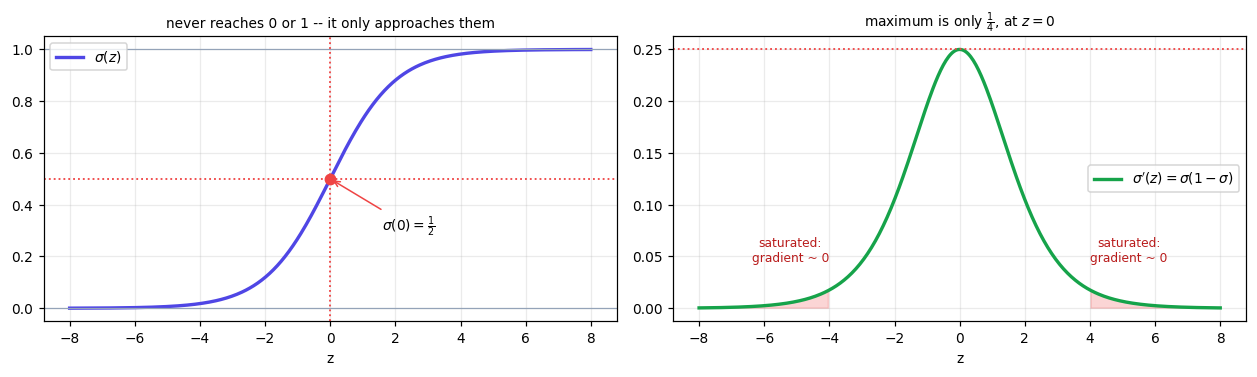

  sigma'( 0) = 2.500e-01
  sigma'( 2) = 1.050e-01
  sigma'( 4) = 1.766e-02
  sigma'( 6) = 2.467e-03
  sigma'(10) = 4.540e-05   <- 10,000x smaller than the peak

Even a modest logit of 6 has already cut the gradient by 100x.


In [2]:
z = np.linspace(-8, 8, 400)
s = 1 / (1 + np.exp(-z))
ds = s * (1 - s)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 3.5))

ax0.plot(z, s, color="#4f46e5", lw=2.2, label=r"$\sigma(z)$")
ax0.axhline(0, color="#94a3b8", lw=.8); ax0.axhline(1, color="#94a3b8", lw=.8)
ax0.axhline(0.5, color="#ef4444", ls=":", lw=1.2)
ax0.axvline(0, color="#ef4444", ls=":", lw=1.2)
ax0.scatter([0], [0.5], color="#ef4444", zorder=5, s=45)
ax0.annotate(r"$\sigma(0)=\frac{1}{2}$", xy=(0, .5), xytext=(1.6, .30), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="#ef4444"))
ax0.set_title("never reaches 0 or 1 -- it only approaches them", fontsize=9)
ax0.set_xlabel("z"); ax0.legend(fontsize=9)

ax1.plot(z, ds, color="#16a34a", lw=2.2, label=r"$\sigma'(z)=\sigma(1-\sigma)$")
ax1.axhline(0.25, color="#ef4444", ls=":", lw=1.2)
ax1.fill_between(z, 0, ds, where=np.abs(z) > 4, color="#ef4444", alpha=0.22)
ax1.text(5.2, .045, "saturated:\ngradient ~ 0", fontsize=8, color="#b91c1c", ha="center")
ax1.text(-5.2, .045, "saturated:\ngradient ~ 0", fontsize=8, color="#b91c1c", ha="center")
ax1.set_title(r"maximum is only $\frac{1}{4}$, at $z=0$", fontsize=9)
ax1.set_xlabel("z"); ax1.legend(fontsize=9)
plt.tight_layout(); plt.show()

for zz in (0, 2, 4, 6, 10):
    d = 1 / (1 + math.exp(-zz)) * (1 - 1 / (1 + math.exp(-zz)))
    print(f"  sigma'({zz:>2}) = {d:.3e}" + ("   <- 10,000x smaller than the peak" if zz == 10 else ""))
print("\nEven a modest logit of 6 has already cut the gradient by 100x.")

### 4.2 The fit, the decision boundary, and the loss surface

BCE has no closed form, but it is still convex — one basin, no traps.

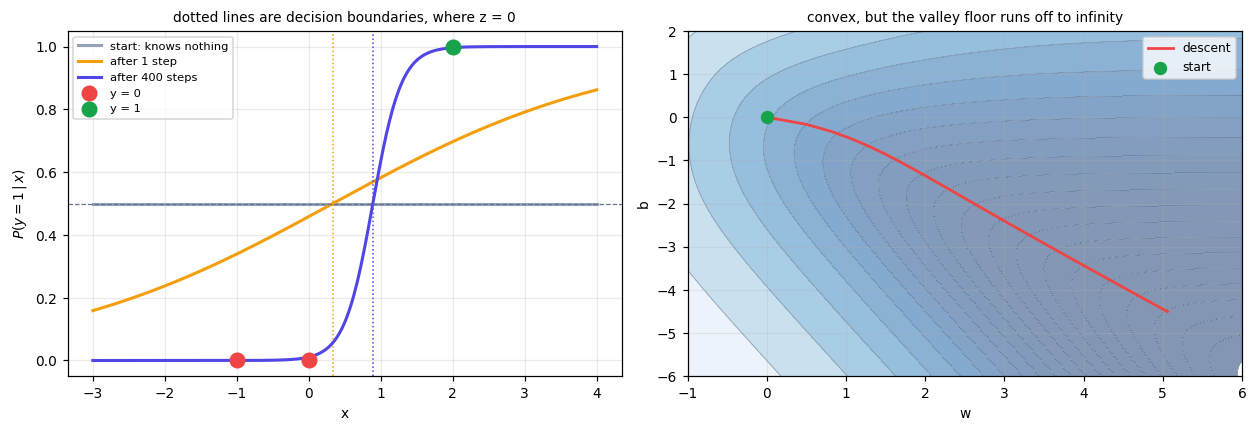

after 400 steps: w = 5.0593, b = -4.5044, loss = 0.004903
Notice the descent path heading off the edge rather than settling.
That is section 9.2, and it is not a bug.


In [3]:
xs, ys = np.array(X_DATA), np.array(Y_DATA)


def sigmoid(v):
    return 1 / (1 + np.exp(-v))


def bce(w, b):
    p = np.clip(sigmoid(w * xs + b), 1e-12, 1 - 1e-12)
    return float(-np.mean(ys * np.log(p) + (1 - ys) * np.log(1 - p)))


def grads(w, b):
    e = sigmoid(w * xs + b) - ys
    return float(np.mean(e * xs)), float(np.mean(e))


def descend(w, b, lr, steps):
    path = [(w, b, bce(w, b))]
    for _ in range(steps):
        gw, gb = grads(w, b)
        w, b = w - lr * gw, b - lr * gb
        path.append((w, b, bce(w, b)))
    return np.array(path)


path = descend(0.0, 0.0, 1.0, 400)
grid = np.linspace(-3, 4, 300)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.0))

for (w, b, lbl, col) in [(0.0, 0.0, "start: knows nothing", "#94a3b8"),
                         (TRUTH["w_1"], TRUTH["b_1"], "after 1 step", "#f59e0b"),
                         (path[-1, 0], path[-1, 1], "after 400 steps", "#4f46e5")]:
    ax0.plot(grid, sigmoid(w * grid + b), lw=2, color=col, label=lbl)
    if w != 0:
        ax0.axvline(-b / w, color=col, ls=":", lw=1)
ax0.scatter(xs[ys == 0], ys[ys == 0], s=90, color="#ef4444", zorder=5, label="y = 0")
ax0.scatter(xs[ys == 1], ys[ys == 1], s=90, color="#16a34a", zorder=5, label="y = 1")
ax0.axhline(0.5, color="#64748b", lw=.8, ls="--")
ax0.set_xlabel("x"); ax0.set_ylabel(r"$P(y=1\,|\,x)$")
ax0.set_title("dotted lines are decision boundaries, where z = 0", fontsize=9)
ax0.legend(fontsize=7.5, loc="upper left")

W, B = np.meshgrid(np.linspace(-1, 6, 220), np.linspace(-6, 2, 220))
Z = np.zeros_like(W)
for xi, yi in zip(xs, ys):
    p = np.clip(sigmoid(W * xi + B), 1e-12, 1 - 1e-12)
    Z += -(yi * np.log(p) + (1 - yi) * np.log(1 - p))
Z /= len(xs)

ax1.contourf(W, B, Z, levels=np.geomspace(Z.min() + 1e-4, Z.max(), 22),
             cmap="Blues_r", alpha=0.5)
ax1.contour(W, B, Z, levels=np.geomspace(Z.min() + 1e-4, Z.max(), 22),
            colors="#94a3b8", linewidths=.6)
ax1.plot(path[:, 0], path[:, 1], "-", color="#ef4444", lw=1.8, label="descent")
ax1.scatter([0], [0], s=60, color="#16a34a", zorder=5, label="start")
ax1.set_xlabel("w"); ax1.set_ylabel("b")
ax1.set_title("convex, but the valley floor runs off to infinity", fontsize=9)
ax1.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"after 400 steps: w = {path[-1,0]:.4f}, b = {path[-1,1]:.4f}, loss = {path[-1,2]:.6f}")
print("Notice the descent path heading off the edge rather than settling.")
print("That is section 9.2, and it is not a bug.")

### 4.3 Cross-entropy versus MSE: the gradient that gives up

Both losses are minimised at the right answer. Only one of them still
*pushes* when the model is confidently wrong.

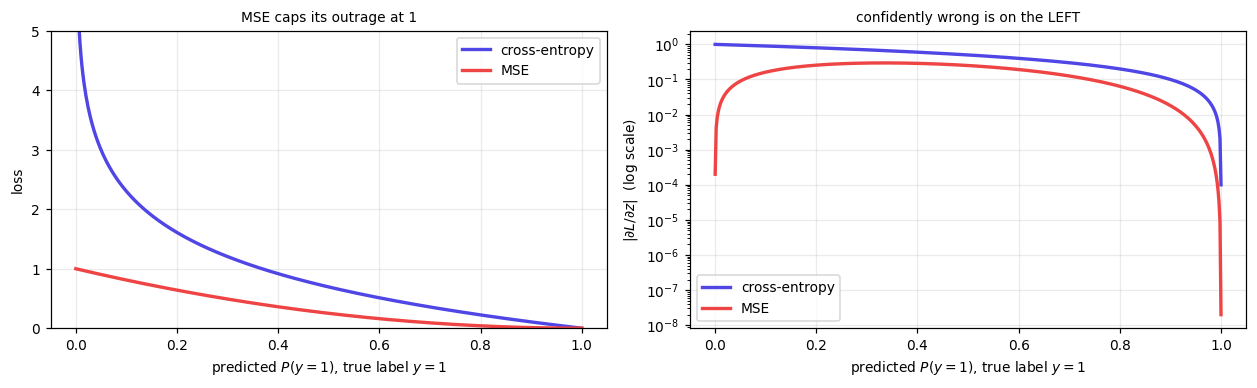

  prediction    BCE |dL/dz|    MSE |dL/dz|      ratio
       0.001       0.999000       0.001996      500.5x
       0.010       0.990000       0.019602       50.5x
       0.100       0.900000       0.162000        5.6x
       0.500       0.500000       0.250000        2.0x
       0.900       0.100000       0.018000        5.6x

Read the first row. The model says 0.001 when the truth is 1 -- it could not
be more wrong -- and MSE responds with a gradient 500 times weaker than
cross-entropy's. MSE is least helpful exactly where help is most needed,
because sigma' has collapsed. Cross-entropy cancels that factor away.


In [4]:
p = np.linspace(1e-4, 1 - 1e-4, 500)
zz = np.log(p / (1 - p))                       # the logit that produces p

bce_loss = -np.log(p)                          # for y = 1
mse_loss = (p - 1) ** 2
bce_grad = p - 1                               # dL/dz, cancellation applied
mse_grad = 2 * (p - 1) * p * (1 - p)           # dL/dz, sigma' survives

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 3.6))

ax0.plot(p, bce_loss, color="#4f46e5", lw=2.2, label="cross-entropy")
ax0.plot(p, mse_loss, color="#ef4444", lw=2.2, label="MSE")
ax0.set_ylim(0, 5); ax0.set_xlabel(r"predicted $P(y=1)$, true label $y=1$")
ax0.set_ylabel("loss"); ax0.set_title("MSE caps its outrage at 1", fontsize=9)
ax0.legend(fontsize=9)

ax1.plot(p, np.abs(bce_grad), color="#4f46e5", lw=2.2, label="cross-entropy")
ax1.plot(p, np.abs(mse_grad), color="#ef4444", lw=2.2, label="MSE")
ax1.set_yscale("log"); ax1.set_xlabel(r"predicted $P(y=1)$, true label $y=1$")
ax1.set_ylabel(r"$|\partial L/\partial z|$  (log scale)")
ax1.set_title("confidently wrong is on the LEFT", fontsize=9)
ax1.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'prediction':>12} {'BCE |dL/dz|':>14} {'MSE |dL/dz|':>14} {'ratio':>10}")
for pv in (0.001, 0.01, 0.1, 0.5, 0.9):
    b_ = abs(pv - 1)
    m_ = abs(2 * (pv - 1) * pv * (1 - pv))
    print(f"{pv:>12.3f} {b_:>14.6f} {m_:>14.6f} {b_/m_:>10.1f}x")

print("""
Read the first row. The model says 0.001 when the truth is 1 -- it could not
be more wrong -- and MSE responds with a gradient 500 times weaker than
cross-entropy's. MSE is least helpful exactly where help is most needed,
because sigma' has collapsed. Cross-entropy cancels that factor away.""")

## 5. Scratch code — pure Python, no imports

Note `stable_sigmoid`: the naive form overflows, and section 9.1 shows it
happening. Getting this right from the start is cheaper than debugging
`nan` later.

In [5]:
def stable_sigmoid(z):
    """Mathematically identical to 1/(1+exp(-z)), but never overflows.

    For z < 0 the naive form computes exp(-z) of a large positive number,
    which overflows. The algebraically equal form exp(z)/(1+exp(z)) uses
    exp of a large NEGATIVE number instead, which simply underflows to 0.
    """
    if z >= 0:
        return 1.0 / (1.0 + math.exp(-z))
    t = math.exp(z)
    return t / (1.0 + t)


def bce_loss(w, b, xs, ys):
    """Binary cross-entropy computed from the LOGIT, so log(0) never happens.

        -[y log s + (1-y) log(1-s)]  =  softplus(z) - y*z
                                     =  max(z,0) + log(1 + exp(-|z|)) - y*z

    which is finite for every input. This is what `from_logits=True` means.
    """
    total = 0.0
    for x, y in zip(xs, ys):
        z = w * x + b
        total += max(z, 0.0) + math.log1p(math.exp(-abs(z))) - y * z
    return total / len(xs)


def bce_gradients(w, b, xs, ys):
    """dL/dw = (1/m) sum (sigma - y) x ;  dL/db = (1/m) sum (sigma - y)"""
    m = len(xs)
    gw = gb = 0.0
    for x, y in zip(xs, ys):
        e = stable_sigmoid(w * x + b) - y
        gw += e * x
        gb += e
    return gw / m, gb / m


def train(xs, ys, lr=1.0, steps=1, w=0.0, b=0.0):
    for _ in range(steps):
        gw, gb = bce_gradients(w, b, xs, ys)
        w, b = w - lr * gw, b - lr * gb          # both from the same old values
    return w, b


# --- reproduce section 3 exactly ---------------------------------------
s0 = stable_sigmoid(0.0)
ds0 = s0 * (1 - s0)
l0 = bce_loss(0.0, 0.0, X_DATA, Y_DATA)
gw0, gb0 = bce_gradients(0.0, 0.0, X_DATA, Y_DATA)
w1, b1 = train(X_DATA, Y_DATA, steps=1)
l1 = bce_loss(w1, b1, X_DATA, Y_DATA)

scratch = {"sigma_0": s0, "dsigma_0": ds0, "loss_0": l0,
           "grad_w": gw0, "grad_b": gb0, "w_1": w1, "b_1": b1, "loss_1": l1}

for k, v in scratch.items():
    ok = "OK " if abs(v - TRUTH[k]) < 1e-9 else "XX "
    print(f"  {ok} {k:<9} = {v:>13.10f}   hand {TRUTH[k]:>13.10f}")
    assert abs(v - TRUTH[k]) < 1e-9, f"scratch {k}"

print(f"\n  log 2 = {math.log(2):.10f}  <- the loss of a model that knows nothing")

  OK  sigma_0   =  0.5000000000   hand  0.5000000000
  OK  dsigma_0  =  0.2500000000   hand  0.2500000000
  OK  loss_0    =  0.6931471806   hand  0.6931471806
  OK  grad_w    = -0.5000000000   hand -0.5000000000
  OK  grad_b    =  0.1666666667   hand  0.1666666667
  OK  w_1       =  0.5000000000   hand  0.5000000000
  OK  b_1       = -0.1666666667   hand -0.1666666667
  OK  loss_1    =  0.4628456536   hand  0.4628456536

  log 2 = 0.6931471806  <- the loss of a model that knows nothing


### 5.1 Gradient check

The cancellation in section 2.4 was the one step most likely to hide an
error, so it gets checked against the definition of a derivative.

In [6]:
def numeric_grad(f, w, b, eps=1e-6):
    return ((f(w + eps, b) - f(w - eps, b)) / (2 * eps),
            (f(w, b + eps) - f(w, b - eps)) / (2 * eps))


f = lambda w, b: bce_loss(w, b, X_DATA, Y_DATA)
print(f"  {'at':<18} {'rel err':>10} {'abs diff':>11}")
print("  " + "-" * 42)
for (w0, b0) in [(0.0, 0.0), (0.5, -1 / 6), (3.0, -2.5), (-2.0, 1.0)]:
    ga = bce_gradients(w0, b0, X_DATA, Y_DATA)
    gn = numeric_grad(f, w0, b0)
    rel = max(abs(a - n) / max(1e-300, abs(a) + abs(n)) for a, n in zip(ga, gn))
    dif = max(abs(a - n) for a, n in zip(ga, gn))
    print(f"  w={w0:>5}, b={b0:>7.3f}  {rel:>10.2e} {dif:>11.2e}")
    assert rel < 1e-5 or dif < 1e-8, "the cancellation in section 2.4 is wrong"

print("\nThe sigma(1-sigma) really does cancel. The gradient is exactly (sigma - y)x.")

  at                    rel err    abs diff
  ------------------------------------------
  w=  0.0, b=  0.000    6.99e-11    6.99e-11
  w=  0.5, b= -0.167    9.24e-11    5.82e-11
  w=  3.0, b= -2.500    1.00e-09    3.38e-11
  w= -2.0, b=  1.000    1.98e-10    9.65e-11

The sigma(1-sigma) really does cancel. The gradient is exactly (sigma - y)x.


## 6. NumPy — vectorized

In [7]:
X_np, y_np = np.array(X_DATA), np.array(Y_DATA)


def np_sigmoid(z):
    """Vectorized stable sigmoid, branching per element rather than globally."""
    out = np.empty_like(z, dtype=float)
    pos, neg = z >= 0, z < 0
    out[pos] = 1 / (1 + np.exp(-z[pos]))
    t = np.exp(z[neg])
    out[neg] = t / (1 + t)
    return out


def np_loss(w, b):
    z = w * X_np + b
    return float(np.mean(np.maximum(z, 0) - y_np * z + np.log1p(np.exp(-np.abs(z)))))


def np_grads(w, b):
    e = np_sigmoid(w * X_np + b) - y_np
    return float(np.mean(e * X_np)), float(np.mean(e))


gw, gb = np_grads(0.0, 0.0)
w1n, b1n = -gw, -gb                     # one step at lr = 1
numpy_res = {
    "sigma_0": float(np_sigmoid(np.array([0.0]))[0]),
    "dsigma_0": float(np_sigmoid(np.array([0.0]))[0] * (1 - np_sigmoid(np.array([0.0]))[0])),
    "loss_0": np_loss(0.0, 0.0), "grad_w": gw, "grad_b": gb,
    "w_1": w1n, "b_1": b1n, "loss_1": np_loss(w1n, b1n),
}
for k, v in numpy_res.items():
    assert abs(v - TRUTH[k]) < 1e-9, f"numpy {k}"
    print(f"  {k:<9} = {v:>13.10f}")

print(f"\nstable sigmoid on extreme logits: "
      f"{np_sigmoid(np.array([-1000.0, 0.0, 1000.0]))}   (no overflow)")

  sigma_0   =  0.5000000000
  dsigma_0  =  0.2500000000
  loss_0    =  0.6931471806
  grad_w    = -0.5000000000
  grad_b    =  0.1666666667
  w_1       =  0.5000000000
  b_1       = -0.1666666667
  loss_1    =  0.4628456536

stable sigmoid on extreme logits: [0.  0.5 1. ]   (no overflow)


## 7. TensorFlow

In [8]:
try:
    import tensorflow as tf
    HAS_TF = True
    print(f"TensorFlow {tf.__version__}")
except ImportError:
    HAS_TF = False
    print("TensorFlow not installed locally -- section skipped. It runs on Kaggle.")

TensorFlow not installed locally -- section skipped. It runs on Kaggle.


In [9]:
if HAS_TF:
    w_tf = tf.Variable(0.0, dtype=tf.float64)
    b_tf = tf.Variable(0.0, dtype=tf.float64)
    xt = tf.constant(X_DATA, dtype=tf.float64)
    yt = tf.constant(Y_DATA, dtype=tf.float64)

    with tf.GradientTape() as tape:
        logits = w_tf * xt + b_tf
        # from_logits=True does exactly the softplus trick from section 5
        loss = tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(labels=yt, logits=logits))
    gw_tf, gb_tf = tape.gradient(loss, [w_tf, b_tf])

    print("autodiff vs our hand-derived cancellation:")
    print(f"  L(0,0)  {float(loss):>13.10f}   hand {TRUTH['loss_0']:>13.10f}")
    print(f"  dL/dw   {float(gw_tf):>13.10f}   hand {TRUTH['grad_w']:>13.10f}")
    print(f"  dL/db   {float(gb_tf):>13.10f}   hand {TRUTH['grad_b']:>13.10f}")

    w_tf.assign_sub(gw_tf); b_tf.assign_sub(gb_tf)
    z1 = w_tf * xt + b_tf
    tf_res = {
        "sigma_0": float(tf.sigmoid(0.0).numpy()),
        "dsigma_0": float((tf.sigmoid(0.0) * (1 - tf.sigmoid(0.0))).numpy()),
        "loss_0": float(loss), "grad_w": float(gw_tf), "grad_b": float(gb_tf),
        "w_1": float(w_tf), "b_1": float(b_tf),
        "loss_1": float(tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(labels=yt, logits=z1))),
    }
    for k in ("w_1", "b_1", "loss_1"):
        print(f"  {k:<7} {tf_res[k]:>13.10f}   hand {TRUTH[k]:>13.10f}")
else:
    tf_res = None

In [10]:
if HAS_TF:
    # The Keras version -- one Dense unit with a sigmoid IS this model.
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(1, activation="sigmoid", input_shape=(1,))
    ])
    model.set_weights([np.zeros((1, 1)), np.zeros(1)])
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1.0),
                  loss="binary_crossentropy")
    h = model.fit(np.array(X_DATA)[:, None], np.array(Y_DATA),
                  epochs=1, batch_size=3, verbose=0)
    kw, kb = model.get_weights()
    print(f"Keras after ONE epoch:  w = {kw[0,0]:.10f}   b = {kb[0]:.10f}")
    print(f"our hand calculation :  w = {TRUTH['w_1']:.10f}   b = {TRUTH['b_1']:.10f}")
    print(f"reported loss        : {h.history['loss'][0]:.10f}   hand {TRUTH['loss_0']:.10f}")
    assert abs(kw[0, 0] - TRUTH["w_1"]) < 1e-6 and abs(kb[0] - TRUTH["b_1"]) < 1e-6
    print("\nKeras took precisely the step we computed on paper.")

## 8. Agreement check

In [11]:
implementations = {"hand (section 3)": TRUTH, "scratch": scratch, "numpy": numpy_res}
if tf_res is not None:
    implementations["tensorflow"] = tf_res

keys = ["sigma_0", "dsigma_0", "loss_0", "grad_w", "grad_b", "w_1", "b_1", "loss_1"]
print(f"{'quantity':<10} " + " ".join(f"{n:>18}" for n in implementations))
print("-" * (11 + 19 * len(implementations)))
for k in keys:
    print(f"{k:<10} " + " ".join(f"{impl[k]:>18.10f}" for impl in implementations.values()))

for name, impl in implementations.items():
    for k in keys:
        assert abs(impl[k] - TRUTH[k]) < 1e-6, f"{name} disagrees on {k}"

skipped = "" if tf_res is not None else "   (tensorflow skipped -- not installed locally)"
print(f"\nAll implementations agree to 1e-6.{skipped}")

quantity     hand (section 3)            scratch              numpy
--------------------------------------------------------------------
sigma_0          0.5000000000       0.5000000000       0.5000000000
dsigma_0         0.2500000000       0.2500000000       0.2500000000
loss_0           0.6931471806       0.6931471806       0.6931471806
grad_w          -0.5000000000      -0.5000000000      -0.5000000000
grad_b           0.1666666667       0.1666666667       0.1666666667
w_1              0.5000000000       0.5000000000       0.5000000000
b_1             -0.1666666667      -0.1666666667      -0.1666666667
loss_1           0.4628456536       0.4628456536       0.4628456536

All implementations agree to 1e-6.   (tensorflow skipped -- not installed locally)


## 9. The silent failures — three of them

### 9.1 The naive sigmoid overflows, and `log(0)` is `-inf`

In [12]:
def naive_sigmoid(z):
    return 1.0 / (1.0 + math.exp(-z))


print("the textbook formula, on perfectly ordinary logits:")
for zv in (0.0, -700.0, -745.0, -746.0):
    try:
        print(f"  naive_sigmoid({zv:>7}) = {naive_sigmoid(zv):.3e}")
    except OverflowError as e:
        print(f"  naive_sigmoid({zv:>7}) -> OverflowError: {e}")
        print(f"  stable_sigmoid({zv:>6}) = {stable_sigmoid(zv):.3e}   <- fine")

print("\nand the loss, computed from probabilities instead of logits:")
for zv in (-40.0, -800.0):
    p = stable_sigmoid(zv)
    naive = "log(0) = -inf -> nan loss" if p == 0.0 else f"{-math.log(max(p, 5e-324)):.4f}"
    print(f"  z = {zv:>7}:  sigma = {p:.3e}   -log(sigma) via probability: {naive}")
    print(f"              from the logit directly: "
          f"{max(zv,0) + math.log1p(math.exp(-abs(zv))) - 1*zv:.4f}   <- always finite")

print("""
Both failures are invisible until they are not. NumPy does not raise on
overflow -- it returns inf with at most a RuntimeWarning you will miss in a
training log, and one inf poisons every subsequent number as nan.

The fix is never to leave the logit. Every framework has a `from_logits`
switch for exactly this reason, and it is not an optimisation -- it is a
correctness fix.""")

the textbook formula, on perfectly ordinary logits:


  naive_sigmoid(    0.0) = 5.000e-01
  naive_sigmoid( -700.0) = 9.860e-305
  naive_sigmoid( -745.0) -> OverflowError: math range error
  stable_sigmoid(-745.0) = 4.941e-324   <- fine
  naive_sigmoid( -746.0) -> OverflowError: math range error
  stable_sigmoid(-746.0) = 0.000e+00   <- fine

and the loss, computed from probabilities instead of logits:
  z =   -40.0:  sigma = 4.248e-18   -log(sigma) via probability: 40.0000
              from the logit directly: 40.0000   <- always finite
  z =  -800.0:  sigma = 0.000e+00   -log(sigma) via probability: log(0) = -inf -> nan loss
              from the logit directly: 800.0000   <- always finite

Both failures are invisible until they are not. NumPy does not raise on
overflow -- it returns inf with at most a RuntimeWarning you will miss in a
training log, and one inf poisons every subsequent number as nan.

The fix is never to leave the logit. Every framework has a `from_logits`
switch for exactly this reason, and it is not an optimisation

### 9.2 Separable data makes the weights run away forever

Our three points can be perfectly separated by a line. Watch what happens.

In [13]:
w, b = 0.0, 0.0
print(f"{'step':>9} {'w':>10} {'b':>10} {'loss':>12} {'P(y=1|x=2)':>13}")
for t in range(1, 200_001):
    gw, gb = np_grads(w, b)
    w, b = w - 0.5 * gw, b - 0.5 * gb
    if t in (10, 100, 1_000, 10_000, 100_000, 200_000):
        print(f"{t:>9,} {w:>10.4f} {b:>10.4f} {np_loss(w, b):>12.8f} "
              f"{np_sigmoid(np.array([w * 2 + b]))[0]:>13.8f}")

print("""
The loss falls forever and never arrives. The weights grow without bound --
slowly, like log(t), but without limit -- and there is no minimum to reach:
the infimum of the loss is 0 and it sits at infinity.

The reason is in the maths. Once every point is on the correct side, scaling
(w, b) by any c > 1 pushes every sigma closer to its label, so the loss
always improves. Nothing stops it.

Consequences you will actually meet:
  - the model becomes absurdly overconfident: P = 0.99999 on evidence that
    only justifies 0.7
  - the weights eventually saturate every sigmoid, so gradients vanish and
    training appears to "finish" when it has merely stalled
  - with float32 the logits eventually overflow

Every practical fix is the same fix: STOP IT GROWING. L2 regularization
(Lesson 17) adds a penalty that grows with |w| so the two forces balance at a
finite point. Early stopping (Lesson 16) just refuses to wait. This runaway
is the single best motivation for regularization, which is why we met it
before meeting the cure.""")

     step          w          b         loss    P(y=1|x=2)
       10     1.3019    -0.7087   0.22200654    0.86932985
      100     3.0871    -2.4969   0.03595108    0.97532976
    1,000     5.2757    -4.7219   0.00394663    0.99706894


   10,000     7.5642    -7.0144   0.00039938    0.99970076


  100,000     9.8652    -9.3159   0.00003999    0.99997001


  200,000    10.5583   -10.0089   0.00002000    0.99998500

The loss falls forever and never arrives. The weights grow without bound --
slowly, like log(t), but without limit -- and there is no minimum to reach:
the infimum of the loss is 0 and it sits at infinity.

The reason is in the maths. Once every point is on the correct side, scaling
(w, b) by any c > 1 pushes every sigma closer to its label, so the loss
always improves. Nothing stops it.

Consequences you will actually meet:
  - the model becomes absurdly overconfident: P = 0.99999 on evidence that
    only justifies 0.7
  - the weights eventually saturate every sigmoid, so gradients vanish and
    training appears to "finish" when it has merely stalled
  - with float32 the logits eventually overflow

Every practical fix is the same fix: STOP IT GROWING. L2 regularization
(Lesson 17) adds a penalty that grows with |w| so the two forces balance at a
finite point. Early stopping (Lesson 16) just refuses to wait. This runaway
is 

### 9.3 Pairing a sigmoid with MSE

It trains. It converges. It is simply much slower, for the reason plotted
in section 4.3 — and on a deep network this difference compounds per layer.

In [14]:
def train_mse(steps, lr=1.0):
    w = b = 0.0
    for _ in range(steps):
        s = np_sigmoid(w * X_np + b)
        d = 2 * (s - y_np) * s * (1 - s) / len(X_np)     # sigma' survives
        w, b = w - lr * float(np.sum(d * X_np)), b - lr * float(np.sum(d))
    return w, b


def train_bce(steps, lr=1.0):
    w = b = 0.0
    for _ in range(steps):
        gw, gb = np_grads(w, b)
        w, b = w - lr * gw, b - lr * gb
    return w, b


print(f"{'steps':>8} {'BCE accuracy':>16} {'MSE accuracy':>16}")
for n in (1, 10, 100, 1000):
    accs = []
    for trainer in (train_bce, train_mse):
        w, b = trainer(n)
        pred = (np_sigmoid(w * X_np + b) >= 0.5).astype(float)
        accs.append(float(np.mean(pred == y_np)))
    print(f"{n:>8} {accs[0]:>16.3f} {accs[1]:>16.3f}")

w_b, b_b = train_bce(1000)
w_m, b_m = train_mse(1000)
print(f"\nafter 1000 steps:")
print(f"  cross-entropy: w = {w_b:7.4f}, b = {b_b:8.4f}")
print(f"  MSE          : w = {w_m:7.4f}, b = {b_m:8.4f}")
print("\nMSE is still crawling out of the flat region cross-entropy escaped immediately.")

   steps     BCE accuracy     MSE accuracy
       1            1.000            1.000
      10            1.000            1.000
     100            1.000            1.000
    1000            1.000            1.000



after 1000 steps:
  cross-entropy: w =  5.9627, b =  -5.4111
  MSE          : w =  3.5897, b =  -3.3009

MSE is still crawling out of the flat region cross-entropy escaped immediately.


## 10. Exercises

Solutions: `solutions/08-logistic-regression-solutions.ipynb`.

In [15]:
# --- Exercise 1 -------------------------------------------------------
# Take the SECOND step by hand from w1 = 1/2, b1 = -1/6 with eta = 1.
# You need sigma(-2/3), sigma(-1/6) and sigma(5/6) -- they are printed in
# section 3.5. Give w2 and b2 to 6 decimals.
ex1_w2 = None
ex1_b2 = None

_w2, _b2 = train(X_DATA, Y_DATA, steps=1, w=TRUTH["w_1"], b=TRUTH["b_1"])
assert ex1_w2 is not None and abs(ex1_w2 - _w2) < 1e-5, f"w2 should be {_w2:.6f}"
assert ex1_b2 is not None and abs(ex1_b2 - _b2) < 1e-5, f"b2 should be {_b2:.6f}"
print(f"Ex 1 OK -- w2 = {_w2:.6f}, b2 = {_b2:.6f}")

AssertionError: w2 should be 0.815042

In [16]:
# --- Exercise 2 -------------------------------------------------------
# What loss does a binary classifier achieve if it outputs 0.5 for everything?
# And a 10-class classifier that outputs 1/10 for everything?
ex2_binary = None
ex2_tenclass = None

assert ex2_binary is not None and abs(ex2_binary - math.log(2)) < 1e-9
assert ex2_tenclass is not None and abs(ex2_tenclass - math.log(10)) < 1e-9
print(f"Ex 2 OK -- log 2 = {math.log(2):.6f}, log 10 = {math.log(10):.6f}")
print("         Memorise these. A loss stuck at log(k) means NOTHING is being learned.")

AssertionError: 

In [17]:
# --- Exercise 3 -------------------------------------------------------
# Prove sigma(-z) = 1 - sigma(z) numerically, then use it to implement
# stable_sigmoid in ONE line with no branch, via math.exp of a negative
# number only. Hint: exp(-abs(z)) is always safe.
def one_line_sigmoid(z):
    return None     # <-- your code


for _z in (-1000.0, -50.0, -1.0, 0.0, 1.0, 50.0, 1000.0):
    _got = one_line_sigmoid(_z)
    assert _got is not None, "implement it"
    assert abs(_got - stable_sigmoid(_z)) < 1e-12, f"wrong at z={_z}: {_got}"
print("Ex 3 OK -- no overflow at z = -1000, and it matches the branching version.")

AssertionError: implement it

In [18]:
# --- Exercise 4 -------------------------------------------------------
# Derive and implement the gradient for LOGISTIC regression with an L2
# penalty:  L = BCE + (lambda/2) w^2.   The penalty applies to w, NOT to b.
# (Why not b? Think about what shifting the boundary costs.)
def l2_gradients(w, b, xs, ys, lam):
    return None     # <-- (gw, gb)


_g = l2_gradients(2.0, -1.0, X_DATA, Y_DATA, 0.5)
_base = bce_gradients(2.0, -1.0, X_DATA, Y_DATA)
assert _g is not None, "return a (gw, gb) tuple"
assert abs(_g[0] - (_base[0] + 0.5 * 2.0)) < 1e-9, "gw should gain lambda*w"
assert abs(_g[1] - _base[1]) < 1e-9, "gb must be unchanged -- no penalty on the bias"
print(f"Ex 4 OK -- the penalty adds lambda*w = {0.5*2.0} to dL/dw and nothing to dL/db.")

AssertionError: return a (gw, gb) tuple

In [19]:
# --- Exercise 5 -------------------------------------------------------
# Section 9.2 showed the weights running away on separable data. Add the L2
# penalty from Exercise 4 and show they now converge. Return the final w
# after 20000 steps with lam = 0.1, lr = 0.5.
def train_l2(xs, ys, lam=0.1, lr=0.5, steps=20000):
    return None     # <-- final (w, b)


_r = train_l2(X_DATA, Y_DATA)
assert _r is not None and len(_r) == 2
assert abs(_r[0]) < 10, f"w should now be bounded, got {_r[0]}"
_r2 = train_l2(X_DATA, Y_DATA, steps=100000)
assert abs(_r[0] - _r2[0]) < 1e-3, "5x more steps should barely move it now"
print(f"Ex 5 OK -- w settles at {_r[0]:.6f} and stays there.")
print("         Unregularized it passed 10 and was still climbing. This is Lesson 17.")

AssertionError: 

In [20]:
# --- Exercise 6 (stretch) ---------------------------------------------
# Generalize to n features using the design-matrix form:
#     grad = (1/m) X^T (sigmoid(X @ theta) - y)
# Fit 3 features + bias and check against the analytic gradient with a
# gradient check.
def fit_logistic(X, y, lr=0.5, steps=5000):
    """X: (m, n) WITHOUT a bias column. Return theta of length n+1."""
    return None     # <-- your code


np.random.seed(2)
_X = np.random.randn(200, 3)
_true = np.array([1.5, -2.0, 0.5, 0.3])
_p = 1 / (1 + np.exp(-(_X @ _true[:3] + _true[3])))
_y = (np.random.rand(200) < _p).astype(float)

_theta = fit_logistic(_X, _y)
assert _theta is not None and len(_theta) == 4, "return 4 parameters"
_Xb = np.hstack([_X, np.ones((200, 1))])
_pred = 1 / (1 + np.exp(-(_Xb @ _theta)))
_acc = np.mean((_pred >= 0.5) == _y)
assert _acc > 0.8, f"accuracy only {_acc:.3f}"
print(f"Ex 6 OK -- accuracy {_acc:.3f}, recovered {np.round(_theta, 3)} vs true {_true}")
print("         The estimates are not exact, and should not be: the labels were")
print("         SAMPLED from those probabilities, not computed from them.")

AssertionError: return 4 parameters

## 11. What you learned

- **$\sigma'(z) = \sigma(z)(1-\sigma(z))$** — a derivative written in terms
  of the forward output, so backprop gets it for free. Its peak is only
  $\tfrac14$, and it collapses exponentially once $|z|$ grows. That collapse
  is saturation, and it returns as the vanishing gradient in Lesson 32.
- **Cross-entropy is derived, not chosen.** It is the negative log-likelihood
  of the probabilistic reading of the output. Anything else is a guess.
- **The $\sigma(1-\sigma)$ cancels exactly**, leaving
  $\partial L/\partial z = \sigma - y$ — the same "error times input" shape as
  Lesson 06, for the same underlying reason. In Lesson 11 this becomes the
  $\delta$ that backprop carries between layers.
- **A binary model that knows nothing scores $\log 2 = 0.693$** (and $\log k$
  for $k$ classes). Keep that number in your head; a loss parked there means
  nothing is being learned.
- **Never leave the logit.** The naive sigmoid overflows, `log(0)` is `-inf`,
  and both produce `nan` with no exception raised. Computing the loss from
  logits via `softplus(z) - yz` is finite everywhere — that is exactly what
  `from_logits=True` does, and it is a correctness fix, not an optimisation.
- **On separable data the weights diverge forever.** The loss keeps improving
  towards an infimum that sits at infinity. This is the clearest motivation
  for regularization you will see, and Exercise 5 already fixed it.
- **The closed form is gone for good.** From here on, gradient descent is not
  one option among several — it is the only one.

### Next

**Lesson 09 — The Perceptron and its Limits.** We go back to 1958, build the
original learning machine, and walk into the XOR wall that stalled the field
for a decade. Understanding precisely *why* a single linear boundary cannot
represent XOR is what makes hidden layers feel inevitable rather than
arbitrary.